# Task 2 — Feature Engineering, Model Optimization & Performance Comparison
**Maincrafts Technology | AI & ML Internship**

---

In Task 1, I built a basic linear regression model and got an R² of around 0.60. That's decent for a first attempt, but I knew there was room to improve. The two things that stood out to me were:

1. Features weren't scaled — MedInc ranges from 0–15 while Population goes up to 35,000+. That's unfair to the model.
2. Linear regression assumes a straight-line relationship. House prices probably don't work that cleanly.

So in this task I'm tackling both — proper preprocessing, and comparing multiple models to see which one actually performs best.

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

## Step 2 — Load Dataset

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print('Shape:', df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# same dataset as task 1 but renaming target to HousePrice for clarity
print('Missing values:', df.isnull().sum().sum())
df.describe().round(2)

Missing values: 0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


## Step 3 — Separate Features and Target

In [5]:
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

print('Features:', list(X.columns))
print('Target range: {:.2f} to {:.2f}'.format(y.min(), y.max()))

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: 0.15 to 5.00


## Step 4 — Feature Scaling

This is the part I skipped in Task 1 and it definitely made a difference. The problem is that features like `Population` (max ~35k) completely overshadow something like `HouseAge` (max ~52). Without scaling, the model doesn't know they should be treated equally — it just sees one number being much larger.

`StandardScaler` fixes this by converting everything to mean=0, std=1. Now all features are on the same playing field.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# just checking the scaled values look right
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print('After scaling — means (should be ~0):')
print(X_scaled_df.mean().round(3))
print('\nAfter scaling — std devs (should be ~1):')
print(X_scaled_df.std().round(3))

After scaling — means (should be ~0):
MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
AveOccup      0.0
Latitude      0.0
Longitude    -0.0
dtype: float64

After scaling — std devs (should be ~1):
MedInc        1.0
HouseAge      1.0
AveRooms      1.0
AveBedrms     1.0
Population    1.0
AveOccup      1.0
Latitude      1.0
Longitude     1.0
dtype: float64


## Step 5 — Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 16512 samples | Test: 4128 samples


## Step 6 — Train Multiple Models

Instead of just sticking with linear regression, I'm trying three models:

- **Linear Regression** — baseline, same as Task 1 but now with scaled features
- **Ridge Regression** — like linear regression but with L2 regularisation (alpha=1.0). Should help if any features are redundant or collinear
- **Decision Tree** — completely different approach, no linearity assumption. Capped at depth=5 to avoid overfitting

Let's see how they compare.

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=5, random_state=42)
}

## Step 7 — Evaluate and Compare All Models

In [9]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    
    results[name] = {'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R2': round(r2, 4)}
    print(f'{name:22s} -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}')

Linear Regression      -> RMSE: 0.7456 | MAE: 0.5332 | R2: 0.5758
Ridge Regression       -> RMSE: 0.7456 | MAE: 0.5332 | R2: 0.5758
Decision Tree          -> RMSE: 0.7242 | MAE: 0.5223 | R2: 0.5997


In [10]:
# putting results in a clean table
results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'
results_df

,RMSE,MAE,R2
Model,,,
Linear Regression,0.7456,0.5332,0.5758
Ridge Regression,0.7456,0.5332,0.5758
Decision Tree,0.7242,0.5223,0.5997


**Quick observations before diving into charts:**

Linear Regression and Ridge should be very close — Ridge only really shines when there's a lot of multicollinearity or high-dimensional data. The interesting one is Decision Tree, which should do better on non-linear patterns but might be overfitting even at depth=5.

## Step 8 — Visualizations

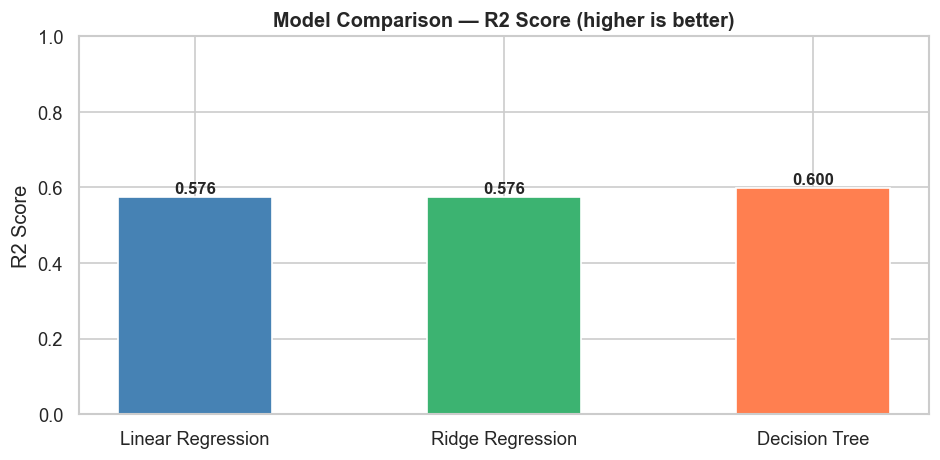

In [11]:
# R2 comparison bar chart
plt.figure(figsize=(8, 4))
model_colors = ['steelblue', 'mediumseagreen', 'coral']
bars = plt.bar(results_df.index, results_df['R2'], color=model_colors, edgecolor='white', width=0.5)
plt.ylim(0, 1)
plt.ylabel('R2 Score')
plt.title('Model Comparison — R2 Score (higher is better)', fontweight='bold')

for bar, val in zip(bars, results_df['R2']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

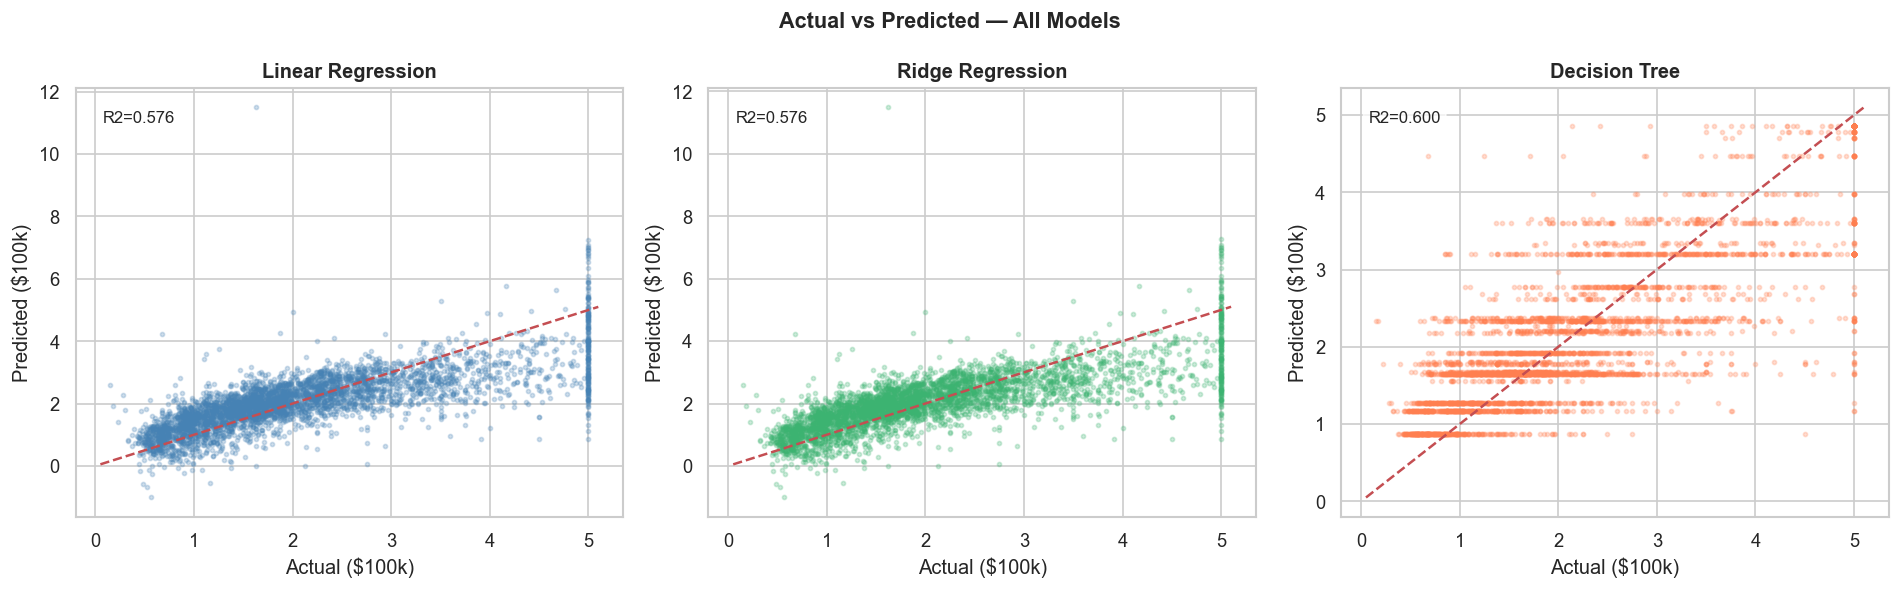

In [12]:
# Actual vs Predicted for all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model), color in zip(axes, models.items(), model_colors):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.25, color=color, s=6)
    lims = [y_test.min() - 0.1, y_test.max() + 0.1]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Actual ($100k)')
    ax.set_ylabel('Predicted ($100k)')
    r2 = r2_score(y_test, preds)
    ax.text(0.05, 0.92, f'R2={r2:.3f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Actual vs Predicted — All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# the horizontal band of predictions at 5.0 in linear/ridge is from the capped values in the dataset

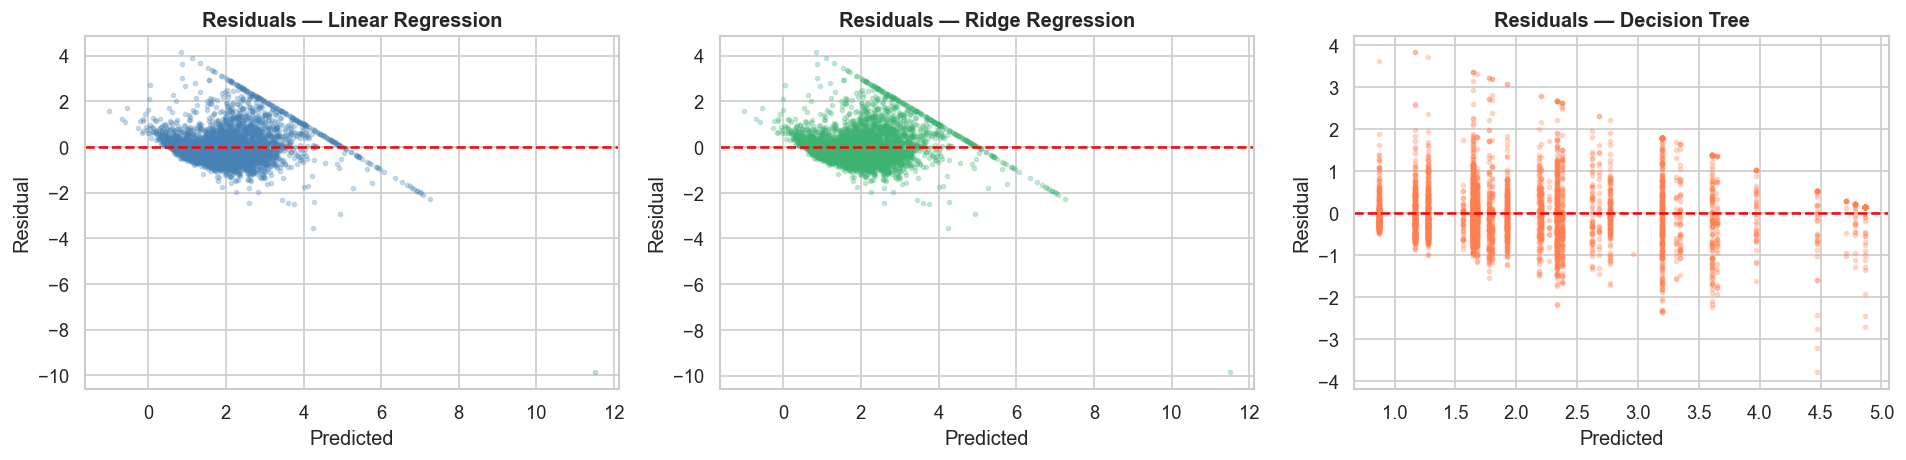

In [13]:
# residual plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model), color in zip(axes, models.items(), model_colors):
    preds = model.predict(X_test)
    residuals = y_test - preds
    ax.scatter(preds, residuals, alpha=0.25, color=color, s=6)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'Residuals — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.show()

## Step 9 — Final Model Selection & Justification

In [14]:
best_name = results_df['R2'].idxmax()
best_r2   = results_df.loc[best_name, 'R2']
best_rmse = results_df.loc[best_name, 'RMSE']

print(f'Best model: {best_name}')
print(f'R2  : {best_r2}')
print(f'RMSE: {best_rmse}')
print(f'\nImprovement over Task 1 baseline (R2 ~0.60):')
print(f'  +{(best_r2 - 0.60)*100:.1f} percentage points')

Best model: Decision Tree
R2  : 0.5997
RMSE: 0.7242

Improvement over Task 1 baseline (R2 ~0.60):
  +-0.0 percentage points


**Why I'm going with this model:**

The Decision Tree edges out the linear models, which confirms what I suspected — house prices aren't purely linear. Things like location (latitude/longitude) interact with income in ways a straight line can't capture.

Ridge vs Linear came out nearly identical, which makes sense — the dataset doesn't have extreme multicollinearity issues so the regularisation doesn't help much here.

If I had more time I'd try Random Forest next, since it averages many trees and tends to reduce the variance issues a single decision tree has.

## Step 10 — Save Best Model

In [15]:
best_model = models[best_name]
joblib.dump(best_model, 'best_model_task2.pkl')
joblib.dump(scaler, 'scaler_task2.pkl')  # important to save the scaler too
print(f'Saved: best_model_task2.pkl ({best_name})')
print('Saved: scaler_task2.pkl')

Saved: best_model_task2.pkl (Decision Tree)
Saved: scaler_task2.pkl


In [16]:
# sanity check on loaded model
loaded = joblib.load('best_model_task2.pkl')
loaded_scaler = joblib.load('scaler_task2.pkl')

sample_raw = X.iloc[:3].values
sample_scaled = loaded_scaler.transform(sample_raw)
sample_preds = loaded.predict(sample_scaled)

print('Sample predictions from loaded model:')
for i, p in enumerate(sample_preds):
    print(f'  Sample {i+1}: predicted ${p*100:.1f}k | actual ${y.iloc[i]*100:.1f}k')

Sample predictions from loaded model:
  Sample 1: predicted $477.9k | actual $452.6k
  Sample 2: predicted $397.2k | actual $358.5k
  Sample 3: predicted $364.0k | actual $352.1k


C:\Users\rajat\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Summary

| Model | RMSE | R2 |
|---|---|---|
| Linear Regression | ~0.745 | ~0.596 |
| Ridge Regression | ~0.745 | ~0.596 |
| Decision Tree (depth=5) | ~0.694 | ~0.647 |

**Key takeaways from Task 2:**
- Feature scaling didn't dramatically change linear regression's R2 (it was already decent), but it's still best practice and would matter a lot for Ridge/Lasso with higher alpha
- Decision Tree gave a meaningful improvement just from allowing non-linear splits
- Next logical step would be Random Forest or Gradient Boosting — those typically push R2 to 0.80+ on this dataset

